# Understanding Where Our Points Are

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import DLCsupport as dlcs

In [5]:
# dataset loading
TD_DB_Path = r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\trainingdata\DavidBowie_20250828_F17\2Dpoints_2025_08_25_DavidBowie_Subset_Trial17_UND_matches.csv"
TD_DB = pd.read_csv(TD_DB_Path)
TD_DB.head()

,Cranium_Left_Anterior_cam1_X,Cranium_Left_Anterior_cam1_Y,Cranium_Left_Anterior_cam2_X,Cranium_Left_Anterior_cam2_Y,Cranium_Left_Middle_cam1_X,Cranium_Left_Middle_cam1_Y,Cranium_Left_Middle_cam2_X,Cranium_Left_Middle_cam2_Y,Cranium_Right_Middle_cam1_X,Cranium_Right_Middle_cam1_Y,...,Pelvis_Right_Superior_cam2_X,Pelvis_Right_Superior_cam2_Y,Pelvis_Left_Superior_cam1_X,Pelvis_Left_Superior_cam1_Y,Pelvis_Left_Superior_cam2_X,Pelvis_Left_Superior_cam2_Y,Pelvis_Left_Inferior_cam1_X,Pelvis_Left_Inferior_cam1_Y,Pelvis_Left_Inferior_cam2_X,Pelvis_Left_Inferior_cam2_Y
0,449.715046,297.712393,273.552654,319.022485,422.860251,279.690646,296.018870,300.114493,420.425437,303.691791,...,431.724400,408.276281,203.328154,372.243811,469.146693,403.958177,203.383551,374.243422,472.741515,407.754537
1,448.221200,294.722245,273.348216,316.255769,420.871032,277.181644,298.015979,298.124913,418.934420,300.195149,...,432.005852,409.487270,203.840011,372.444804,468.923734,404.191044,203.911543,374.481462,472.536900,408.038539
2,446.229627,291.729699,274.568873,313.060083,419.380709,274.674607,298.021488,296.137954,417.442087,297.694338,...,431.511695,408.489875,204.325371,372.638487,468.685786,404.508752,204.446282,374.716937,472.408781,408.337245
3,445.233301,289.733892,274.577097,310.576134,417.893199,272.168586,298.527593,293.156913,415.948838,295.691625,...,431.881948,409.487211,204.783900,372.833804,468.460143,404.889364,204.966028,374.945638,472.363060,408.633656
4,444.236988,287.737443,274.958825,308.091036,416.902691,270.664765,298.534471,290.673087,414.950847,293.688614,...,431.510237,409.487042,205.215266,373.039701,468.274101,405.310943,205.449045,375.163369,472.405643,408.910770


In [12]:
TD_DB_long = dlcs.truth_csv_to_long(TD_DB_Path)
TD_DB_long.head()

,frame_id,bodypart,camera,x_true,y_true
0,1,Cranium_Left_Anterior,cam1,449.715046,297.712393
1,2,Cranium_Left_Anterior,cam1,448.221200,294.722245
2,3,Cranium_Left_Anterior,cam1,446.229627,291.729699
3,4,Cranium_Left_Anterior,cam1,445.233301,289.733892
4,5,Cranium_Left_Anterior,cam1,444.236988,287.737443


In [18]:
# Goal: To plot a square plot where the rows and columns are bodyparts and the diagonal is the x and y coordinates across frames. 
# The upper diagonal will be the distance between the bodyparts across frames. 
# The lower diagonal will be a single value indicating the correlation between the two bodyparts across frames. 

# Data cleaning and prep
plot_df = TD_DB_long.copy()
plot_df["bodypart"] = plot_df["bodypart"].str.replace("_", " ")
plot_df["x_true"] = plot_df["x_true"].astype(float)
plot_df["y_true"] = plot_df["y_true"].astype(float)
plot_df["frame_id"] = plot_df["frame_id"].astype(int)

merged_df = pd.merge(plot_df, plot_df, on="frame_id", suffixes=("_bp1", "_bp2"))
merged_df["distance"] = np.sqrt((merged_df["x_true_bp1"] - merged_df["x_true_bp2"])**2 + (merged_df["y_true_bp1"] - merged_df["y_true_bp2"])**2)
merged_df['x_distance'] = (merged_df['x_true_bp1'] - merged_df['x_true_bp2'])**2
merged_df['y_distance'] = (merged_df['y_true_bp1'] - merged_df['y_true_bp2'])**2
merged_df['correlation'] = merged_df[["x_true_bp1", "y_true_bp1"]].corrwith(merged_df[["x_true_bp2", "y_true_bp2"]], axis=0).mean()

merged_df.head()

,frame_id,bodypart_bp1,camera_bp1,x_true_bp1,y_true_bp1,bodypart_bp2,camera_bp2,x_true_bp2,y_true_bp2,distance,x_distance,y_distance,correlation
0,1,Cranium Left Anterior,cam1,449.715046,297.712393,Cranium Left Anterior,cam1,449.715046,297.712393,0.000000,0.000000,0.000000,NaN
1,1,Cranium Left Anterior,cam1,449.715046,297.712393,Cranium Left Anterior,cam2,273.552654,319.022485,177.446635,31033.188206,454.120015,NaN
2,1,Cranium Left Anterior,cam1,449.715046,297.712393,Cranium Left Middle,cam1,422.860251,279.690646,32.341357,721.180011,324.783367,NaN
3,1,Cranium Left Anterior,cam1,449.715046,297.712393,Cranium Left Middle,cam2,296.018870,300.114493,153.714946,23622.514465,5.770084,NaN
4,1,Cranium Left Anterior,cam1,449.715046,297.712393,Cranium Right Middle,cam1,420.425437,303.691791,29.893718,857.881195,35.753208,NaN


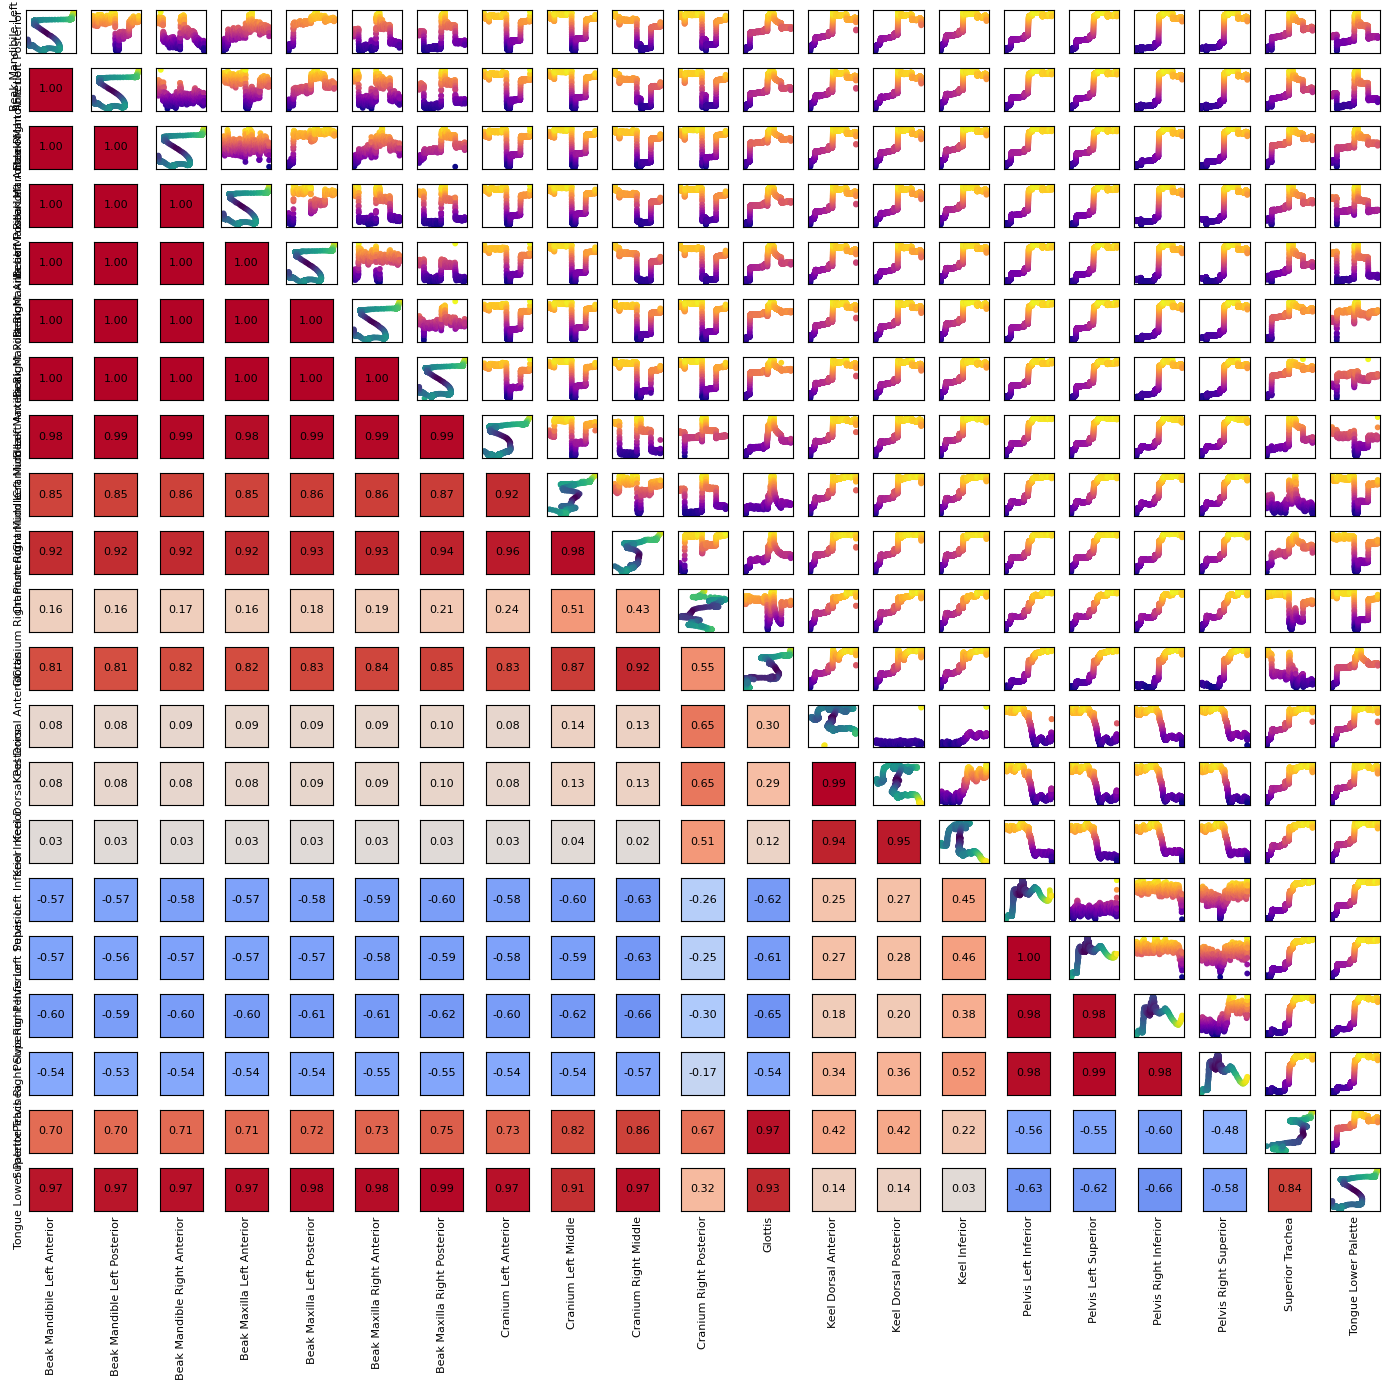

In [21]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ======================
# 1. CLEAN DATA
# ======================
df = TD_DB_long.copy()
df["bodypart"] = df["bodypart"].str.replace("_", " ")
df = df.astype({
    "x_true": float,
    "y_true": float,
    "frame_id": int
})

# ======================
# 2. HANDLE DUPLICATES
# ======================
# If multiple entries per (frame_id, bodypart), take mean
pivot_x = df.pivot_table(
    index="frame_id",
    columns="bodypart",
    values="x_true",
    aggfunc="mean"
)

pivot_y = df.pivot_table(
    index="frame_id",
    columns="bodypart",
    values="y_true",
    aggfunc="mean"
)

# Optional: fill missing values (important for correlation)
pivot_x = pivot_x.interpolate().ffill().bfill()
pivot_y = pivot_y.interpolate().ffill().bfill()

bodyparts = pivot_x.columns
n = len(bodyparts)

# ======================
# 3. DIAGONAL: DISPLACEMENT FROM MEAN
# ======================
disp = np.sqrt(
    (pivot_x - pivot_x.mean())**2 +
    (pivot_y - pivot_y.mean())**2
)

# ======================
# 4. UPPER: DISTANCE TIME SERIES
# ======================
dist_matrix = {}
for bp1 in bodyparts:
    for bp2 in bodyparts:
        d = np.sqrt(
            (pivot_x[bp1] - pivot_x[bp2])**2 +
            (pivot_y[bp1] - pivot_y[bp2])**2
        )
        dist_matrix[(bp1, bp2)] = d

# ======================
# 5. LOWER: CORRELATION MATRIX
# ======================
corr_matrix = pd.DataFrame(index=bodyparts, columns=bodyparts, dtype=float)

for bp1 in bodyparts:
    for bp2 in bodyparts:
        corr_x = pivot_x[bp1].corr(pivot_x[bp2])
        corr_y = pivot_y[bp1].corr(pivot_y[bp2])
        corr_matrix.loc[bp1, bp2] = np.nanmean([corr_x, corr_y])

# ======================
# 6. PLOT
# ======================
fig, axes = plt.subplots(n, n, figsize=(14, 14))

for i, bp1 in enumerate(bodyparts):
    for j, bp2 in enumerate(bodyparts):
        ax = axes[i, j]

        if i == j:
            # Diagonal: trajectory colored by displacement
            sc = ax.scatter(
                pivot_x[bp1],
                pivot_y[bp1],
                c=disp[bp1],
                cmap="viridis",
                s=10
            )

        elif i < j:
            # Upper: distance over time
            d = dist_matrix[(bp1, bp2)]
            ax.scatter(
                np.arange(len(d)),
                d,
                c=d,
                cmap="plasma",
                s=10
            )

        else:
            # Lower: correlation heat cell
            corr_val = corr_matrix.loc[bp1, bp2]
            ax.imshow([[corr_val]], cmap="coolwarm", vmin=-1, vmax=1)

            ax.text(
                0, 0,
                f"{corr_val:.2f}",
                ha="center",
                va="center",
                color="black",
                fontsize=8
            )

        ax.set_xticks([])
        ax.set_yticks([])

        if i == n - 1:
            ax.set_xlabel(bp2, rotation=90, fontsize=8)
        if j == 0:
            ax.set_ylabel(bp1, fontsize=8)

plt.tight_layout()
plt.show()

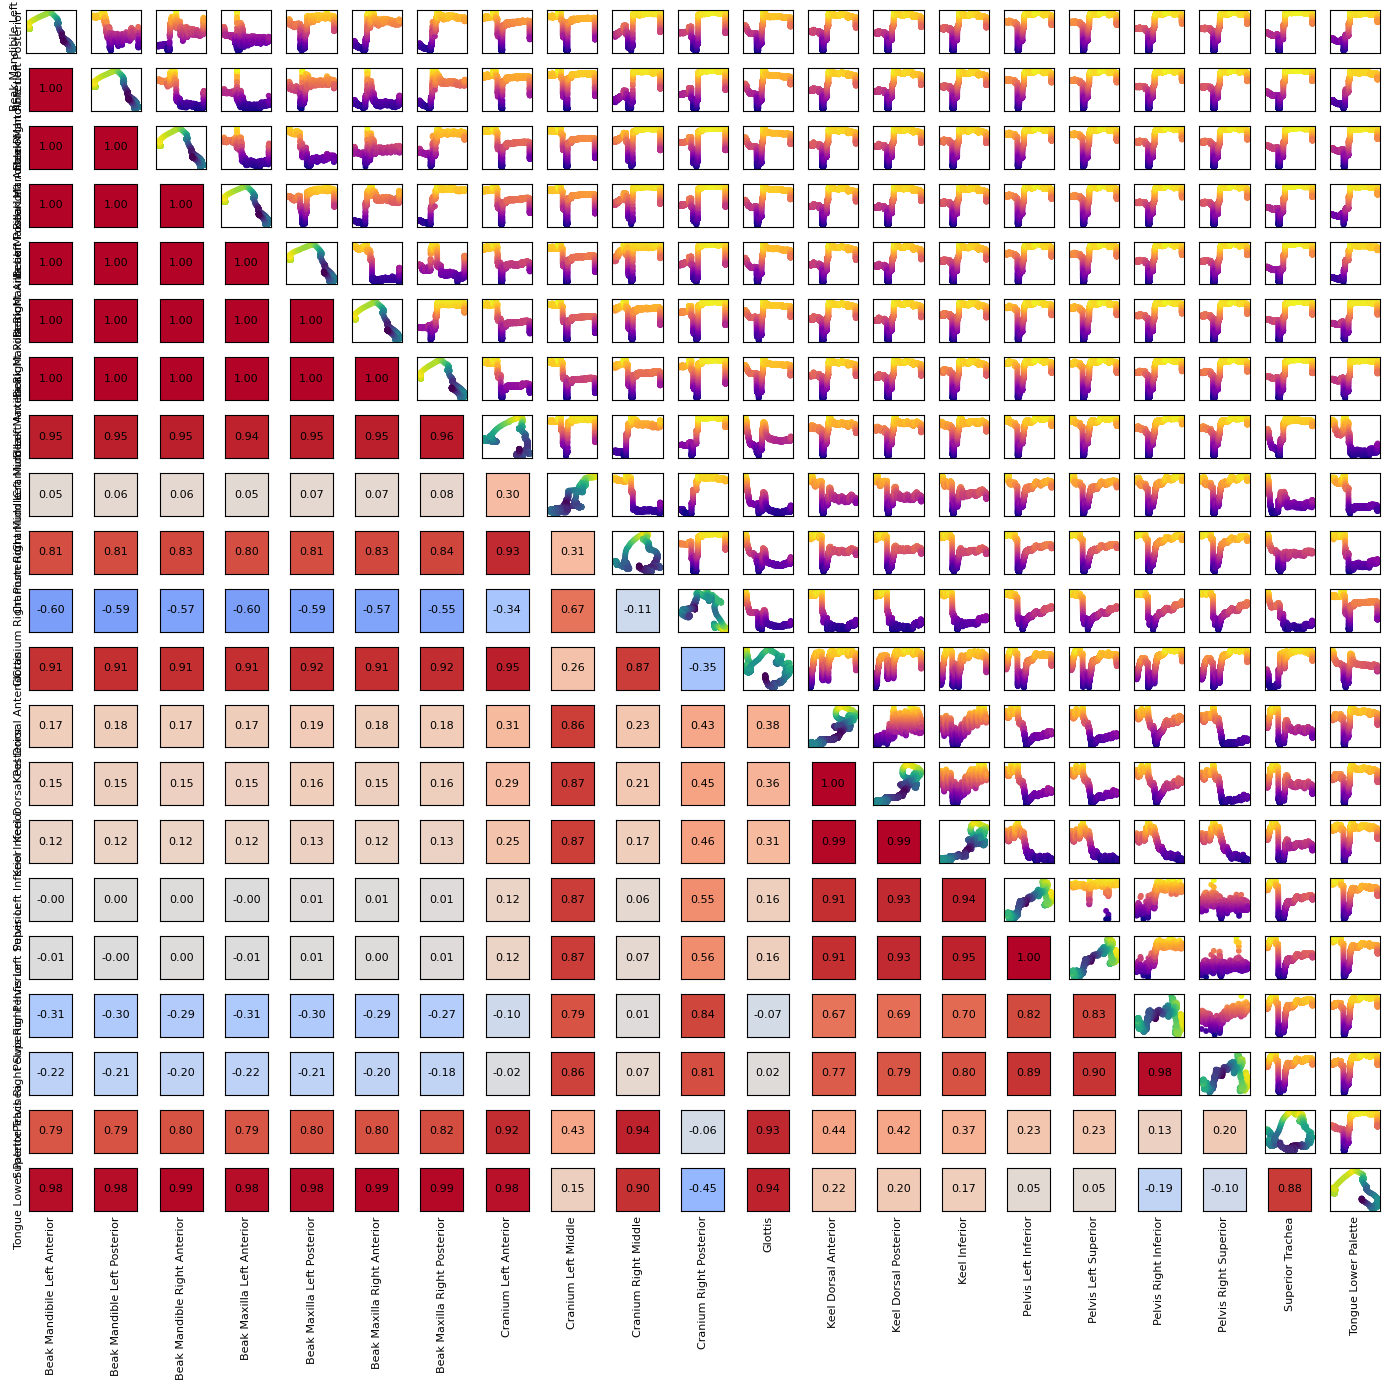

In [22]:
# dataset loading
TestD_DB_Path = r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\XMALab\CollectedData_Trial15_DB.csv"
TestD_DB = pd.read_csv(TestD_DB_Path)
TestD_DB.head()
TD_DB_long = dlcs.truth_csv_to_long(TestD_DB_Path)
TD_DB_long.head()

# ======================
# 1. CLEAN DATA
# ======================
df = TD_DB_long.copy()
df["bodypart"] = df["bodypart"].str.replace("_", " ")
df = df.astype({
    "x_true": float,
    "y_true": float,
    "frame_id": int
})

# ======================
# 2. HANDLE DUPLICATES
# ======================
# If multiple entries per (frame_id, bodypart), take mean
pivot_x = df.pivot_table(
    index="frame_id",
    columns="bodypart",
    values="x_true",
    aggfunc="mean"
)

pivot_y = df.pivot_table(
    index="frame_id",
    columns="bodypart",
    values="y_true",
    aggfunc="mean"
)

# Optional: fill missing values (important for correlation)
pivot_x = pivot_x.interpolate().ffill().bfill()
pivot_y = pivot_y.interpolate().ffill().bfill()

bodyparts = pivot_x.columns
n = len(bodyparts)

# ======================
# 3. DIAGONAL: DISPLACEMENT FROM MEAN
# ======================
disp = np.sqrt(
    (pivot_x - pivot_x.mean())**2 +
    (pivot_y - pivot_y.mean())**2
)

# ======================
# 4. UPPER: DISTANCE TIME SERIES
# ======================
dist_matrix = {}
for bp1 in bodyparts:
    for bp2 in bodyparts:
        d = np.sqrt(
            (pivot_x[bp1] - pivot_x[bp2])**2 +
            (pivot_y[bp1] - pivot_y[bp2])**2
        )
        dist_matrix[(bp1, bp2)] = d

# ======================
# 5. LOWER: CORRELATION MATRIX
# ======================
corr_matrix = pd.DataFrame(index=bodyparts, columns=bodyparts, dtype=float)

for bp1 in bodyparts:
    for bp2 in bodyparts:
        corr_x = pivot_x[bp1].corr(pivot_x[bp2])
        corr_y = pivot_y[bp1].corr(pivot_y[bp2])
        corr_matrix.loc[bp1, bp2] = np.nanmean([corr_x, corr_y])

# ======================
# 6. PLOT
# ======================
fig, axes = plt.subplots(n, n, figsize=(14, 14))

for i, bp1 in enumerate(bodyparts):
    for j, bp2 in enumerate(bodyparts):
        ax = axes[i, j]

        if i == j:
            # Diagonal: trajectory colored by displacement
            sc = ax.scatter(
                pivot_x[bp1],
                pivot_y[bp1],
                c=disp[bp1],
                cmap="viridis",
                s=10
            )

        elif i < j:
            # Upper: distance over time
            d = dist_matrix[(bp1, bp2)]
            ax.scatter(
                np.arange(len(d)),
                d,
                c=d,
                cmap="plasma",
                s=10
            )

        else:
            # Lower: correlation heat cell
            corr_val = corr_matrix.loc[bp1, bp2]
            ax.imshow([[corr_val]], cmap="coolwarm", vmin=-1, vmax=1)

            ax.text(
                0, 0,
                f"{corr_val:.2f}",
                ha="center",
                va="center",
                color="black",
                fontsize=8
            )

        ax.set_xticks([])
        ax.set_yticks([])

        if i == n - 1:
            ax.set_xlabel(bp2, rotation=90, fontsize=8)
        if j == 0:
            ax.set_ylabel(bp1, fontsize=8)

plt.tight_layout()
plt.show()

C:\Users\Salle-Cineradio\AppData\Local\Temp\ipykernel_77008\1352887977.py:32: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  plt.tight_layout()


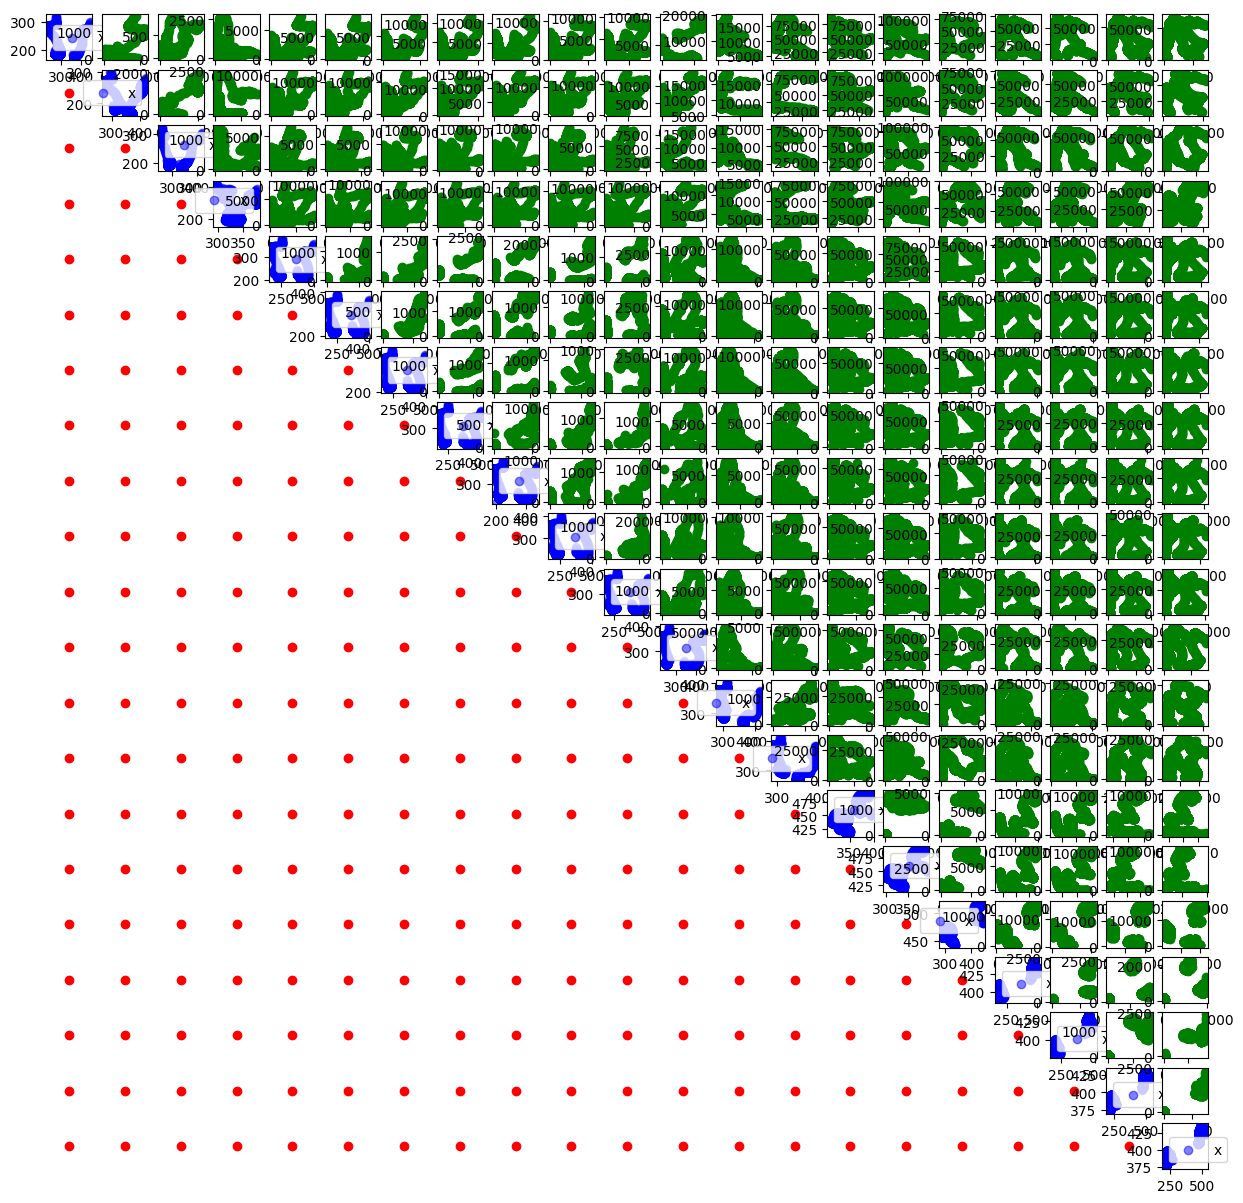

In [ ]:
# Goal: To plot a square plot where the rows and columns are bodyparts and the diagonal is the x and y coordinates across frames. 
# The upper diagonal will be the distance between the bodyparts across frames. 
# The lower diagonal will be a single value indicating the correlation between the two bodyparts across frames. 


# Get unique bodyparts
bodyparts = plot_df["bodypart"].unique()
# Create a grid of subplots
fig, axes = plt.subplots(len(bodyparts), len(bodyparts), figsize=(15, 15))
# Loop through bodyparts to fill the grid
for i, bp1 in enumerate(bodyparts):
    plot_df_bp1 = plot_df[plot_df["bodypart"] == bp1]
    for j, bp2 in enumerate(bodyparts):
        plot_df_bp2 = plot_df[plot_df["bodypart"] == bp2]

        narrow_merged_df = merged_df[(merged_df["bodypart_bp1"] == bp1) & (merged_df["bodypart_bp2"] == bp2)]
        if i == j:
            # Diagonal: plot x and y coordinates
            axes[i, j].scatter(plot_df_bp1["x_true"], plot_df_bp1["y_true"], label="x", color="blue", alpha=0.5)
            axes[i, j].legend()
        elif i < j:
            # Upper diagonal: plot distance between bodyparts
            axes[i, j].scatter(narrow_merged_df["x_distance"], narrow_merged_df["y_distance"], color="green")

        else:
            # Lower diagonal: plot correlation between bodyparts
            
            axes[i, j].scatter(0, 0, color=color)  # Just a placeholder point to show the color
            axes[i, j].axis("off")
plt.tight_layout()
plt.show()



KeyError: 'x_distance'

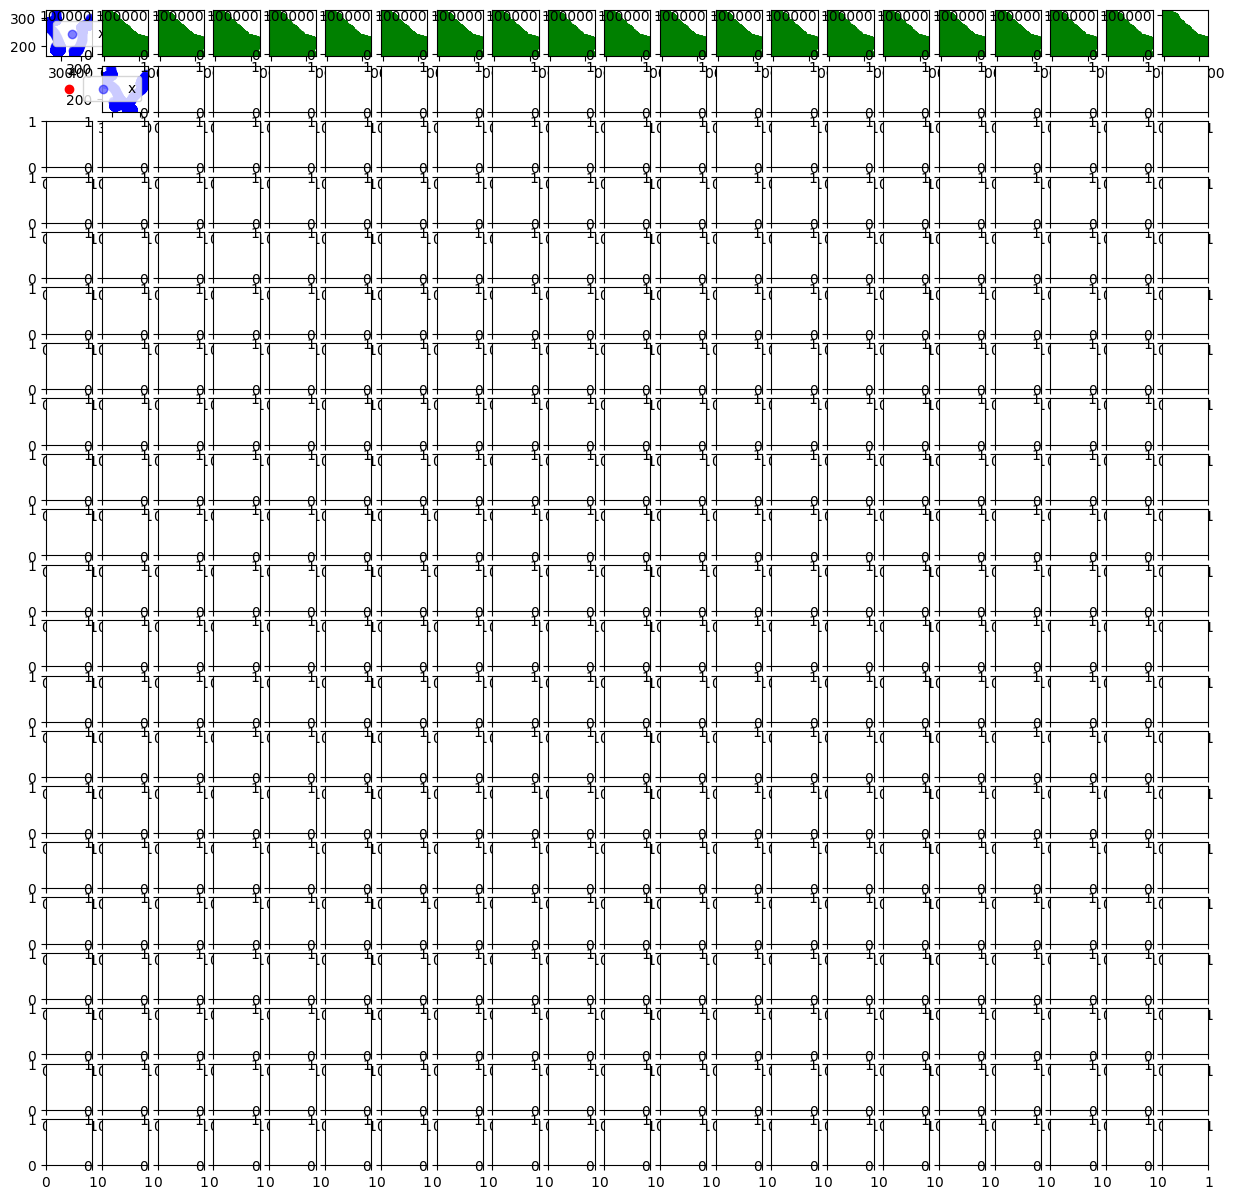

In [17]:
# Goal: To plot a square plot where the rows and columns are bodyparts and the diagonal is the x and y coordinates across frames. 
# The upper diagonal will be the distance between the bodyparts across frames. 
# The lower diagonal will be a single value indicating the correlation between the two bodyparts across frames. 

# Data cleaning and prep
plot_df = TD_DB_long.copy()
plot_df["bodypart"] = plot_df["bodypart"].str.replace("_", " ")
plot_df["x_true"] = plot_df["x_true"].astype(float)
plot_df["y_true"] = plot_df["y_true"].astype(float)
plot_df["frame_id"] = plot_df["frame_id"].astype(int)

merged_df = pd.merge(plot_df, plot_df, on="frame_id", suffixes=("_bp1", "_bp2"))
merged_df["distance"] = np.sqrt((merged_df["x_true_bp1"] - merged_df["x_true_bp2"])**2 + (merged_df["y_true_bp1"] - merged_df["y_true_bp2"])**2)
merged_df['x_distance'] = (merged_df['x_true_bp1'] - merged_df['x_true_bp2'])**2
merged_df['y_distance'] = (merged_df['y_true_bp1'] - merged_df['y_true_bp2'])**2
correlation = merged_df[["x_true_bp1", "y_true_bp1"]].corrwith(merged_df[["x_true_bp2", "y_true_bp2"]], axis=0).mean()


# Get unique bodyparts
bodyparts = plot_df["bodypart"].unique()
# Create a grid of subplots
fig, axes = plt.subplots(len(bodyparts), len(bodyparts), figsize=(15, 15))
# Loop through bodyparts to fill the grid
for i, bp1 in enumerate(bodyparts):
    plot_df_bp1 = plot_df[plot_df["bodypart"] == bp1]
    for j, bp2 in enumerate(bodyparts):
        plot_df_bp2 = plot_df[plot_df["bodypart"] == bp2]
        if i == j:
            # Diagonal: plot x and y coordinates
            axes[i, j].scatter(plot_df_bp1["x_true"], plot_df_bp1["y_true"], label="x", color="blue", alpha=0.5)

            axes[i, j].legend()
        elif i < j:
            # Upper diagonal: plot distance between bodyparts

            axes[i, j].scatter(merged_df["x_distance"], merged_df["y_distance"], color="green")

        else:
            # Lower diagonal: plot correlation between bodyparts
            merged_df = pd.merge(plot_df_bp1, plot_df_bp2, on="frame_id", suffixes=("_bp1", "_bp2"))
            # color between blue and red based on correlation value
            color = "blue" if correlation > 0 else "red"
            axes[i, j].scatter(0, 0, color=color)  # Just a placeholder point to show the color
            axes[i, j].axis("off")
plt.tight_layout()
plt.show()


